In [28]:
import pandas as pd
import sqlite3 as sq
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

In [2]:
customers = pd.read_csv(r"C:\Users\anand\Downloads\olist_customers_dataset (1).csv")

orders = pd.read_csv(r"C:\Users\anand\Downloads\olist_orders_dataset.csv")

order_items = pd.read_csv(r"C:\Users\anand\Downloads\olist_order_items_dataset.csv")

payments = pd.read_csv(r"C:\Users\anand\Downloads\olist_order_payments_dataset.csv")

products = pd.read_csv(r"C:\Users\anand\Downloads\olist_products_dataset.csv")

reviews = pd.read_csv(r"C:\Users\anand\Downloads\olist_order_reviews_dataset.csv")

sellers = pd.read_csv(r"C:\Users\anand\Downloads\olist_sellers_dataset.csv")

geolocation=pd.read_csv(r"C:\Users\anand\Downloads\olist_geolocation_dataset.csv")


# DATA CLEANING AND REFORMATING

In [3]:
orders.rename(columns={"order_purchase_timestamp":"purchased_at","order_approved_at ":"ordered_at","order_delivered_carrier_date":"delivered_carrier_date","order_delivered_customer_date":"delivered_customer_date","order_estimated_delivery_date":"estimated_delivery_date"},inplace=True)
orders["purchased_at"]=pd.to_datetime(orders["purchased_at"])
orders["order_approved_at"]=pd.to_datetime(orders["order_approved_at"])
orders["delivered_carrier_date"]=pd.to_datetime(orders["delivered_carrier_date"])
orders["delivered_customer_date"]=pd.to_datetime(orders["delivered_customer_date"])
orders["estimated_delivery_date"]=pd.to_datetime(orders["estimated_delivery_date"])

In [4]:
order_items["shipping_limit_date"]=pd.to_datetime(order_items["shipping_limit_date"])

In [5]:
payments["payment_type"]=payments["payment_type"].replace({"not_defined":"cod"})

In [6]:
reviews["review_creation_date"]=pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"]=pd.to_datetime(reviews["review_answer_timestamp"])

In [ ]:
## sqlite3 db connection

In [7]:
conn = sq.connect("olist.db")
cursor = conn.cursor()
customers.to_sql("customers", conn, if_exists="replace", index=False)

orders.to_sql("orders", conn, if_exists="replace", index=False)

order_items.to_sql("order_items", conn, if_exists="replace", index=False)

payments.to_sql("payments", conn, if_exists="replace", index=False)

products.to_sql("products", conn, if_exists="replace", index=False)

reviews.to_sql("reviews", conn, if_exists="replace", index=False)

sellers.to_sql("sellers", conn, if_exists="replace", index=False)

geolocation.to_sql("geolocation",conn,if_exists="replace",index=False)

1000163

# *DELAY PERCENTAGE OVERALL*

In [41]:
pd.read_sql("""
select ROUND(AVG(case when julianday(delivered_customer_date)-julianday(purchased_at) > julianday(estimated_delivery_date)-julianday(purchased_at) then 1 else 0 end ) * 100.0,0) as delayed_percentage
from orders
where order_status != 'canceled' and order_status != 'unavailable';
""",conn)

,delayed_percentage
0,8.0


# *Delay contribution BY PRODUCT CATEGORY*

In [43]:
query="""
WITH t AS (
    SELECT SUM(CASE WHEN julianday(estimated_delivery_date)-julianday(purchased_at) < julianday(delivered_customer_date) - julianday(purchased_at) THEN 1 ELSE 0 END) AS delayed_delivery_count
    FROM orders
    where order_status != 'canceled' and order_status != 'unavailable'
)
SELECT c.product_category_name,ROUND(COUNT(
    DISTINCT CASE 
    WHEN julianday(estimated_delivery_date)-julianday(purchased_at) < julianday(delivered_customer_date) - julianday(purchased_at) THEN a.order_id  
    END
)*100.0/(SELECT delayed_delivery_count FROM t),0) as percentage_contribution_in_delayed_orders
FROM orders as a
join order_items as b
on a.order_id=b.order_id
join products as c
on c.product_id=b.product_id
where a.order_status NOT IN ('canceled','unavailable')
group by product_category_name
order by 2 desc
limit 10
"""
pd.read_sql(query,conn)

,product_category_name,percentage_contribution_in_delayed_orders
0,cama_mesa_banho,10.0
1,beleza_saude,10.0
2,moveis_decoracao,7.0
3,esporte_lazer,7.0
4,relogios_presentes,6.0
5,informatica_acessorios,6.0
6,utilidades_domesticas,5.0
7,telefonia,4.0
8,ferramentas_jardim,4.0
9,brinquedos,4.0


# *ORDER BY DAYS X HOURS HEAT MAP*

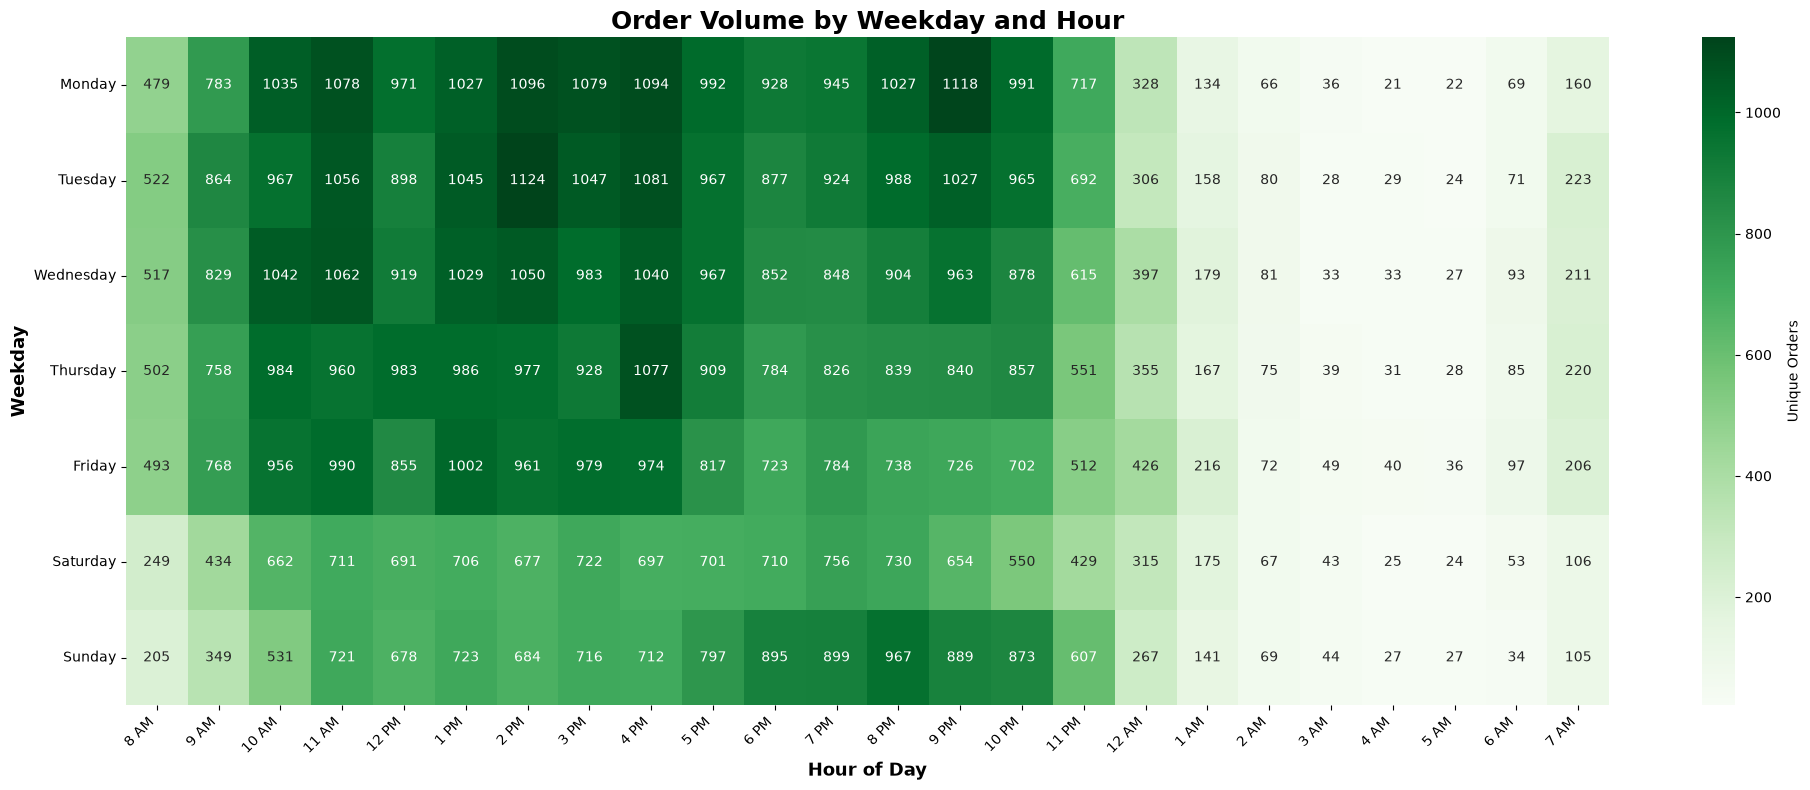

In [10]:
data=pd.DataFrame({
    "weekday":orders["purchased_at"].dt.day_name(),
    "Time":orders["purchased_at"].dt.hour,
    "order_id":orders["order_id"]
})
weekday_order=["Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"]
hour_order = [
    "8 AM", "9 AM", "10 AM", "11 AM",
    "12 PM", "1 PM", "2 PM", "3 PM",
    "4 PM", "5 PM", "6 PM", "7 PM",
    "8 PM", "9 PM", "10 PM", "11 PM",
    "12 AM", "1 AM", "2 AM", "3 AM",
    "4 AM", "5 AM", "6 AM", "7 AM"
]
heatmap=data.pivot_table(
    index="weekday",
    columns="Time",
    values="order_id",
    aggfunc="nunique",
    fill_value=0
)
heatmap=heatmap.reindex(weekday_order)
column_order=[]
for h in heatmap.columns:
    hour=h%12
    if hour==0:
        hour=12
    if(h<12):
        column_order.append(str(hour) + " AM")
    else :
        column_order.append(str(hour) + " PM")

heatmap.columns=column_order
heatmap=heatmap.reindex(columns=hour_order)
plt.figure(figsize=(20, 8))

sns.heatmap(
    heatmap,
    cmap="Greens",           # Color palette
    annot=True,                # Show values inside cells
    fmt="d",                   # Integer formatting
    linewidths=0,            # Cell borders
    linecolor="white",
    cbar_kws={"label": "Unique Orders"}
)

plt.title(
    "Order Volume by Weekday and Hour",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Hour of Day",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Weekday",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# *Operational time between purchase and item delivery for optimisation*

In [11]:
query="""
WITH T AS (
SELECT ((JULIANDAY(order_approved_at)-JULIANDAY(purchased_at))*24) AS a,
((JULIANDAY(delivered_carrier_date)-JULIANDAY(order_approved_at))*24) AS b,
((JULIANDAY(delivered_customer_date)-JULIANDAY(delivered_carrier_date))*24) AS c,
((JULIANDAY(delivered_customer_date)-julianday(purchased_at))*24) AS t
FROM orders
WHERE order_status NOT IN ('canceled','unavailable')
AND purchased_at IS NOT NULL
AND order_approved_at IS NOT NULL
AND delivered_carrier_date IS NOT NULL
AND delivered_customer_date IS NOT NULL
)
SELECT (ROUND((SUM(a)/SUM(t))*100)) AS TIME_PER_BW_PURCHASE_AND_CONFRMTN,
(ROUND((SUM(b)/SUM(t))*100)) AS TIME_PER_BW_CONFRMTN_AND_DISPATCH,
(ROUND((SUM(c)/SUM(t))*100)) AS TIME_PER_BW_DISPATCH_DELIVERY
FROM T
"""
pd.read_sql(query,conn)

,TIME_PER_BW_PURCHASE_AND_CONFRMTN,TIME_PER_BW_CONFRMTN_AND_DISPATCH,TIME_PER_BW_DISPATCH_DELIVERY
0,3.0,22.0,74.0


In [44]:
query="""
WITH T AS (SELECT CAST(((julianday(order_approved_at)-julianday(purchased_at))*24)+0.9999 AS INTEGER) as TIME_bw_PURCHASE_AND_APPROVAL,
CAST((julianday(delivered_carrier_date)-julianday(order_approved_at))+0.9999 AS INTEGER)as TIME_bw_APPROVAL_AND_DISPATCH,
CAST((julianday(delivered_customer_date)-julianday(delivered_carrier_date))+0.9999 AS INTEGER) as TIME_bw_DISPATCH_AND_DELIVERY
FROM orders
WHERE order_status NOT IN ('canceled','unavailable')
AND purchased_at IS NOT NULL
AND order_approved_at IS NOT NULL
AND delivered_carrier_date IS NOT NULL
AND delivered_customer_date IS NOT NULL
)
SELECT ROUND(AVG(TIME_bw_PURCHASE_AND_APPROVAL)) AS AVG_APPROVAL_IN_HOURS,ROUND(AVG(TIME_bw_APPROVAL_AND_DISPATCH)) AS AVG_DISPATCH_DAYS_BY_SELLER,ROUND(AVG(TIME_bw_DISPATCH_AND_DELIVERY)) AS AVG_TIME_BW_DISPATCH_DELIVERY_IN_DAYS
FROM T

"""
data=pd.read_sql(query,conn)
data

,AVG_APPROVAL_IN_HOURS,AVG_DISPATCH_DAYS_BY_SELLER,AVG_TIME_BW_DISPATCH_DELIVERY_IN_DAYS
0,11.0,3.0,10.0


# **HOW MUCH MORE IS AVG CUSTOMER SPENDING WITH EMI OPTIONS**

In [13]:
query="""
with t as (
select order_id,sum(payment_value) as order_value,max(payment_installments) as installments
from payments
group by order_id
)
select round(avg(order_value)) as avg_order_val_with_financing_EMI
from t
where installments>1
"""
pd.read_sql(query,conn)

,avg_order_val_with_financing_EMI
0,199.0


In [14]:
query="""
with t as (
select order_id,sum(payment_value) as order_value,max(payment_installments) as installments
from payments
group by order_id
having count(*)=1
)
select round(avg(order_value)) as avg_order_val_without_financing_EMI
from t
where installments<2
"""
pd.read_sql(query,conn)

,avg_order_val_without_financing_EMI
0,121.0


* 65% More spending on avg order with emi

# *Seller Revenue and Avgerage Rating*

In [15]:
query="""
WITH T AS(
select oi.seller_id,max(r.review_score) as rating,sum(oi.price) as price
from order_items as oi
join reviews as r
on oi.order_id=r.order_id
group by oi.seller_id,oi.order_id
)
select seller_id,sum(price) as SELLER_REVENUE,round(avg(rating),1) as SELLER_RATING_AVG,
round((sum(price)*1.0/(SELECT SUM(price) from order_items)*100),2) as PERCENTAGE_SHARE_OF_TOTAL_REVENUE
from T
group by seller_id
order by 2 desc,3 desc,4 desc
limit 10
"""
pd.read_sql(query,conn)

,seller_id,SELLER_REVENUE,SELLER_RATING_AVG,PERCENTAGE_SHARE_OF_TOTAL_REVENUE
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,4.1,1.69
1,53243585a1d6dc2643021fd1853d8905,222776.05,4.1,1.64
2,4a3ca9315b744ce9f8e9374361493884,202999.12,3.8,1.49
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,4.3,1.43
4,7c67e1448b00f6e969d365cea6b010ab,189417.67,3.5,1.39
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,4.2,1.30
6,da8622b14eb17ae2831f4ac5b9dab84a,162723.37,4.2,1.20
7,7a67c85e85bb2ce8582c35f2203ad736,142325.49,4.2,1.05
8,1025f0e2d44d7041d6cf58b6550e0bfa,140513.14,4.0,1.03
9,955fee9216a65b617aa5c0531780ce60,135241.70,4.1,1.00


# *Seller Ranking Based on a Composite KPI (30% Revenue, 30% Customer Satisfaction, 25% Delivery Performance, 15% Order Volume) against higest performing seller*

In [49]:
query="""
with t1 as (
select oi.seller_id,o.order_id,sum(oi.price) as price,max(r.review_score) as rating,o.delivered_customer_date as delivered,o.estimated_delivery_date as estimated
from orders as o
join order_items as oi
on o.order_id=oi.order_id
join reviews as r
on o.order_id=r.order_id
group by oi.seller_id,oi.order_id
),
t2 as(
select seller_id,order_id,price,rating, (case when delivered <= estimated then 1 else 0 end) as ontime
from t1
),
t3 as(
select seller_id,sum(price) as price
from t2
group by 1
),
t4 as (
select seller_id,count(*) as order_delivered
from t2
group by 1
)
select seller_id, round((sum(price)*1.0/(select max(price) from t3)* 0.3 + (sum(ontime)*1.0/count(*)) * 0.3 + avg(rating)/5* 0.25 + count(*)*1.0/(select max(order_delivered) from t4) * 0.15)*100)as seller_score
from t2
group by seller_id
order by 2 desc
"""
pd.read_sql(query,conn)

,seller_id,seller_score
0,4a3ca9315b744ce9f8e9374361493884,86.0
1,4869f7a5dfa277a7dca6462dcf3b52b2,86.0
2,53243585a1d6dc2643021fd1853d8905,81.0
3,da8622b14eb17ae2831f4ac5b9dab84a,80.0
4,fa1c13f2614d7b5c4749cbc52fecda94,78.0
...,...,...
3090,15aec03fe4cf30dfa574cf550f5ff5ff,5.0
3091,15ac3c501e2599e4917316fde5c5669a,5.0
3092,154bdf805377afea75a3bd158e9eab10,5.0
3093,0aa124728afc1131dff5655f4c6f487b,5.0


# *Is there any correlation between delivery delay and customer satisfaction*

In [17]:
query="""
select o.order_id,r.review_score,julianday(o.delivered_customer_date)-julianday(o.estimated_delivery_date) as delay
from orders as o
join reviews as r
on o.order_id=r.order_id
where o.order_status not in ("canceled","unavailable") and o.delivered_customer_date is not NULL
"""
data=pd.read_sql(query,conn)
data
[corr, p_value] = spearmanr(data["delay"], data["review_score"]) ## speramanr() returns two data correlation and p_value
print("Spearman Correlation:", corr)
print("P-value:", p_value)

Spearman Correlation: -0.17826011846876594
P-value: 0.0


* A statistically significant but weak negative correlation was observed between delivery delay and customer review score (ρ = -0.178, p < 0.001). This indicates that customers tend to give slightly lower ratings as delivery delays increase. However, the weak correlation suggests that delivery delay is only one of several factors influencing customer satisfaction.

# *Is there any correlation between package vloume and delivery delay*

correlation coefficent: -0.02033280925421588
P value: 2.6956720665764946e-10


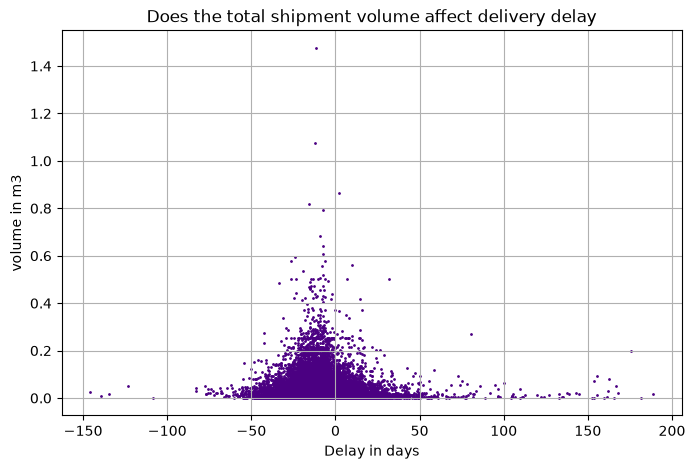

In [45]:
query="""
with t as(select sum(p.product_length_cm*p.product_height_cm*p.product_width_cm)/1000000.0 as volume,
(julianday(o.delivered_customer_date)-julianday(estimated_delivery_date)) as delay
from order_items as oi
join products as p
on oi.product_id=p.product_id
join orders as o
on o.order_id=oi.order_id
where o.order_status not in ('canceled','unavailable') and delivered_customer_date is not null and estimated_delivery_date is not null
group by oi.order_id
)
select* 
from t 
where volume is not null and delay is not null
"""
data=pd.read_sql(query,conn)
data
corr,p_value=spearmanr(data["volume"],data["delay"])
print("correlation coefficent:",corr)
print("P value:",p_value)
plt.figure(figsize=(8,5))
plt.scatter(data["delay"],data["volume"],alpha=1,s=1,color='Indigo')
plt.title("Does the total shipment volume affect delivery delay")
plt.xlabel("Delay in days")
plt.ylabel("volume in m3")
plt.grid(True)

*A statistically significant but negligible negative correlation (ρ = −0.0203, p < 0.001) was found between total shipment volume and delivery delay. This indicates that shipment volume has little practical association with delivery delays, suggesting that operational and logistics factors are more influential than shipment size.

# *Is there any correlation between seller processing time and delivery delay*

correlation coefficent: 0.17272947697014066
P value: 0.0


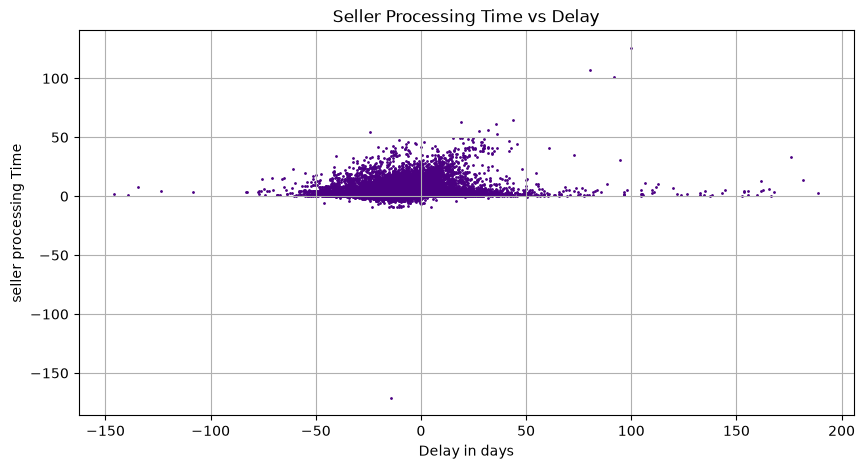

In [19]:
query="""
SELECT ((JULIANDAY(delivered_carrier_date)-JULIANDAY(order_approved_at))) AS seller_processing_time,
((JULIANDAY(delivered_customer_date)-JULIANDAY(estimated_delivery_date))) AS delay
FROM orders
WHERE order_status NOT IN ('canceled','unavailable')
AND purchased_at IS NOT NULL
AND order_approved_at IS NOT NULL
AND delivered_carrier_date IS NOT NULL
AND delivered_customer_date IS NOT NULL
AND order_id IS NOT NULL
"""
data=pd.read_sql(query,conn)
data
[corr,p_value]=spearmanr(data["delay"],data["seller_processing_time"])
print("correlation coefficent:",corr)
print("P value:",p_value)
plt.figure(figsize=(10,5))
plt.scatter(data["delay"],data["seller_processing_time"],alpha=1,s=1,color='Indigo')
plt.title("Seller Processing Time vs Delay")
plt.xlabel("Delay in days")
plt.ylabel("seller processing Time")
plt.grid(True)

* Seller processing time shows a statistically significant but weak positive association with delivery delay (ρ = 0.173, p < 0.001), suggesting that slower seller dispatch contributes to late deliveries but is only one of several influencing factors.

# *Is there any correlation between Transit Time and delivery delay*

correlation coefficent: 0.2345648662257146
P value: 0.0


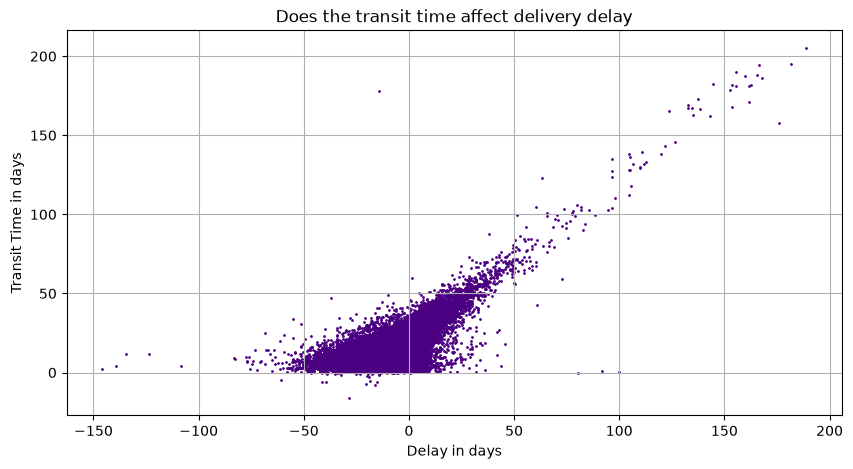

In [20]:
query="""
SELECT ((JULIANDAY(delivered_customer_date)-JULIANDAY(delivered_carrier_date))) AS transit_time,
((JULIANDAY(delivered_customer_date)-JULIANDAY(estimated_delivery_date))) AS delay
FROM orders
WHERE order_status NOT IN ('canceled','unavailable')
AND purchased_at IS NOT NULL
AND order_approved_at IS NOT NULL
AND delivered_carrier_date IS NOT NULL
AND delivered_customer_date IS NOT NULL
AND order_id IS NOT NULL
"""
data=pd.read_sql(query,conn)
data
[corr,p_value]=spearmanr(data["delay"],data["transit_time"])
print("correlation coefficent:",corr)
print("P value:",p_value)
plt.figure(figsize=(10,5))
plt.scatter(data["delay"],data["transit_time"],alpha=1,s=1,color='Indigo')
plt.title("Does the transit time affect delivery delay")
plt.xlabel("Delay in days")
plt.ylabel("Transit Time in days")
plt.grid(True)

* Spearman's rank correlation analysis revealed a statistically significant weak positive correlation between carrier transit time and delivery delay (ρ = 0.235, p < 0.001). This indicates that orders spending more time in transit generally tend to experience higher delivery delays.

In [46]:
query="""
select geolocation_zip_code_prefix,avg(geolocation_lat) as lat , avg(geolocation_lng) as lng
from geolocation
group by 1
"""
geolocation=pd.read_sql(query,conn)
geolocation.to_sql("geo_avg",conn,if_exists="replace",index=False)

19015

correlation coefficent: 0.18121864266950327
P value: 0.0


count    96000.000000
mean       602.108145
std        593.916047
min          0.000000
25%        189.317367
50%        435.633100
75%        800.275152
max       8677.911622
Name: customer_dis, dtype: float64

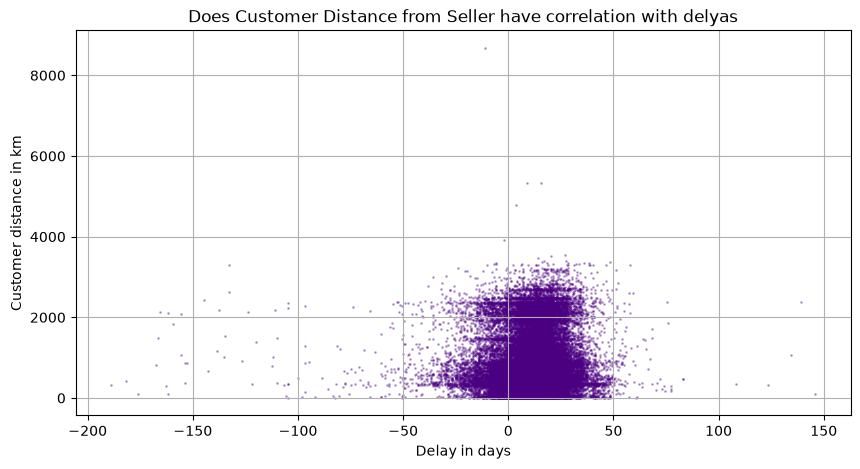

In [47]:
query="""
select o.order_id,g1.lat as slat,g1.lng as slng,g2.lat as clat,g2.lng as clng,(julianday(o.estimated_delivery_date)-julianday(o.delivered_customer_date)) as delay
from customers as c
join orders as o
on c.customer_id=o.customer_id
join order_items as oi
on o.order_id=oi.order_id
join sellers as s
on s.seller_id=oi.seller_id
join geo_avg as g1
on g1.geolocation_zip_code_prefix=s.seller_zip_code_prefix
join geo_avg as g2
on g2.geolocation_zip_code_prefix=c.customer_zip_code_prefix
where o.estimated_delivery_date is not null 
and o.delivered_customer_date is not null 
and o.order_id is not null 
and g1.lat is not null 
and g1.lng is not null 
and g2.lat is not null 
and g2.lng is not null
"""
df=pd.read_sql(query,conn)
df
R = 6371
lat1 = np.radians(df['slat'])
lat2 = np.radians(df['clat'])
lon1 = np.radians(df['slng'])
lon2 = np.radians(df['clng'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2)**2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
)

df['distance_km'] = 2 * R * np.arcsin(np.sqrt(a))
df=(
    df.groupby("order_id",as_index=False)
    .agg(
        customer_dis=("distance_km","max"),
        delay=("delay","max")
    )
)
corr,p_value=[corr,p_value]=spearmanr(df["delay"],df["customer_dis"])
print("correlation coefficent:",corr)
print("P value:",p_value)
plt.figure(figsize=(10,5))
plt.title("Does Customer Distance from Seller have correlation with delyas")
plt.xlabel("Delay in days")
plt.ylabel("Customer distance in km")
plt.grid(True)
plt.scatter(df["delay"],df["customer_dis"],alpha=0.3,s=1,color='Indigo')
df["customer_dis"].describe()


* Business conclusion: Seller-customer distance has a statistically significant but weak positive relationship with delivery delays (Spearman ρ ≈ 0.18), suggesting that longer shipping distances are associated with slightly higher delivery delays, but distance alone is not a strong predictor of delays.

# *Hence the most significant contributer to delayed deliveries is transit time and need optimisation as well as the company should improve inventory managment system to enhance seller processing time.* #

In [40]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_id                 99441 non-null  str           
 1   customer_id              99441 non-null  str           
 2   order_status             99441 non-null  str           
 3   purchased_at             99441 non-null  datetime64[us]
 4   order_approved_at        99281 non-null  datetime64[us]
 5   delivered_carrier_date   97658 non-null  datetime64[us]
 6   delivered_customer_date  96476 non-null  datetime64[us]
 7   estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [55]:
query="""
WITH t1 AS (
    SELECT
        oi.seller_id,
        o.order_id,
        SUM(oi.price) AS price,
        MAX(r.review_score) AS rating,
        o.delivered_customer_date AS delivered,
        o.estimated_delivery_date AS estimated
    FROM orders AS o
    JOIN order_items AS oi
        ON o.order_id = oi.order_id
    JOIN reviews AS r
        ON o.order_id = r.order_id
    GROUP BY
        oi.seller_id,
        o.order_id,
        o.delivered_customer_date,
        o.estimated_delivery_date
),

t2 AS (
    SELECT
        seller_id,
        order_id,
        price,
        rating,
        CASE
            WHEN delivered <= estimated THEN 1
            ELSE 0
        END AS ontime
    FROM t1
)

SELECT
    seller_id,
    SUM(price) AS revenue,
    ROUND(AVG(rating), 2) AS avg_rating,
    ROUND(SUM(ontime) * 1.0 / COUNT(*), 4) AS delivery_rate,
    COUNT(*) AS order_volume
FROM t2
GROUP BY seller_id
ORDER BY revenue DESC;
"""
data=pd.read_sql(query,conn)
data.describe()

,revenue,avg_rating,delivery_rate,order_volume
count,3095.000000,3095.000000,3095.000000,3095.000000
mean,4411.368352,3.985441,0.852730,32.313409
std,13987.043983,0.962510,0.252829,105.139763
min,3.500000,1.000000,0.000000,1.000000
25%,209.550000,3.750000,0.837700,2.000000
50%,821.480000,4.170000,0.950000,6.000000
75%,3299.760000,4.600000,1.000000,21.500000
max,229472.630000,5.000000,1.000000,1854.000000


In [57]:
## to remove value bias in revenue and order_volume we are using log transformation
data['log_revenue'] = np.log1p(data['revenue'])
data['log_order_volume'] = np.log1p(data['order_volume'])
data.describe()

,revenue,avg_rating,delivery_rate,order_volume,log_revenue,log_order_volume
count,3095.000000,3095.000000,3095.000000,3095.000000,3095.000000,3095.000000
mean,4411.368352,3.985441,0.852730,32.313409,6.751831,2.265494
std,13987.043983,0.962510,0.252829,105.139763,1.842947,1.373052
min,3.500000,1.000000,0.000000,1.000000,1.504077,0.693147
25%,209.550000,3.750000,0.837700,2.000000,5.349723,1.098612
50%,821.480000,4.170000,0.950000,6.000000,6.712324,1.945910
75%,3299.760000,4.600000,1.000000,21.500000,8.101901,3.113268
max,229472.630000,5.000000,1.000000,1854.000000,12.343543,7.525640


In [62]:
from sklearn.preprocessing import StandardScaler

features = data[['log_revenue',
                 'avg_rating',
                 'delivery_rate',
                 'log_order_volume']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)
X_scaled.mean(axis=0)


array([-7.34648386e-17, -3.53549536e-16,  3.76507298e-16,  1.46929677e-16])

In [63]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

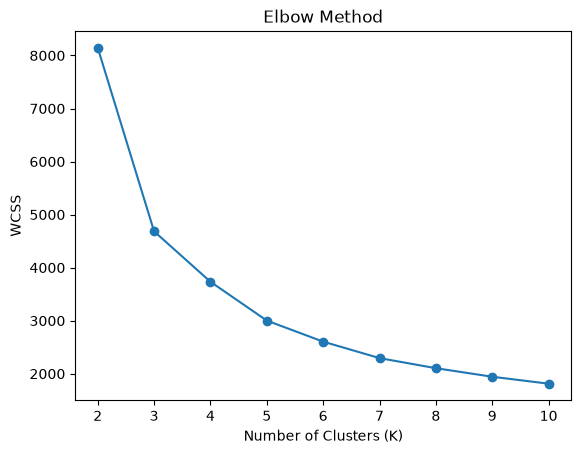

In [64]:
plt.plot(range(2, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [65]:
from sklearn.metrics import silhouette_score

for k in [3, 4, 5]:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 3: Silhouette Score = 0.4048
K = 4: Silhouette Score = 0.3374
K = 5: Silhouette Score = 0.3508


In [103]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

data['cluster'] = kmeans.fit_predict(X_scaled)

In [104]:
data['cluster'].value_counts().sort_index()

cluster
0    1598
1    1165
2     332
Name: count, dtype: int64

In [100]:
cluster_profile = data.groupby('cluster')[
    ['revenue', 'avg_rating', 'delivery_rate', 'order_volume']
].mean().round(2)

cluster_profile

,revenue,avg_rating,delivery_rate,order_volume
cluster,,,,
0,542.50,4.34,0.95,4.41
1,10807.15,4.07,0.90,79.13
2,590.18,1.98,0.25,2.32


In [96]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

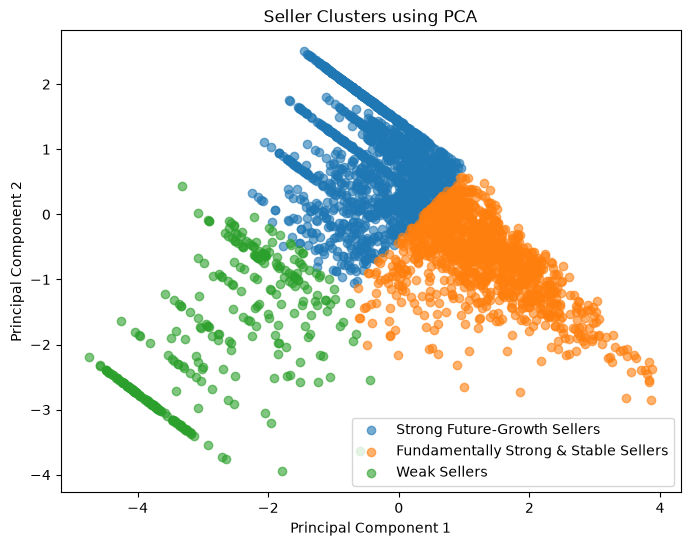

In [97]:
cluster_labels = {
    0: 'Strong Future-Growth Sellers',
    1: 'Fundamentally Strong & Stable Sellers',
    2: 'Weak Sellers'
}

data['seller_segment'] = data['cluster'].map(cluster_labels)

plt.figure(figsize=(8, 6))

for cluster, label in cluster_labels.items():
    mask = data['cluster'] == cluster
    
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        alpha=0.6,
        label=label
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Seller Clusters using PCA')
plt.legend()
plt.show()

In [76]:
Strong_future_growth_selers = data.loc[data['cluster'] == 0, 'seller_id'].tolist()

fundamentally_strong_stable_sellers = data.loc[data['cluster'] == 1, 'seller_id'].tolist()

weak_sellers = data.loc[data['cluster'] == 2, 'seller_id'].tolist()

In [ ]:
conn.